In [1]:
import jax
import optax
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

We take a super simple Liesel model here

In [2]:
xval = 2.0 * jax.random.normal(jax.random.key(42), (10_000,)) + 3.0

In [3]:
m = lsl.Var.new_param(0.0, name="m")
s = lsl.Var.new_param(1.0, name="s")
s.transform(tfb.Exp())
x = lsl.Var.new_obs(
    xval,
    distribution=lsl.Dist(tfd.Normal, loc=m, scale=s),
    name="x",
)
p = lsl.Model([x])

In [4]:
res = (
    opt.LieselVI(
        p,
        optimizers=optax.adam(learning_rate=1e-3),
        loss_monitor=opt.EmaTrainLossMonitor(effective_window=1.0),
        loss="mvn_tril",
    )
    .build_engine()
    .fit()
)

liesel.optim.engine - INFO - Initializing optimization at epoch 0


Initializing:   0%|          | 0/1000 [00:00<?, ?it/s]

Train=7.160, Monitor=7.160:   1%|          | 10/1000 [00:00<01:18, 12.56it/s]

Train=6.496, Monitor=6.496:   6%|▋         | 65/1000 [00:00<00:14, 66.18it/s]

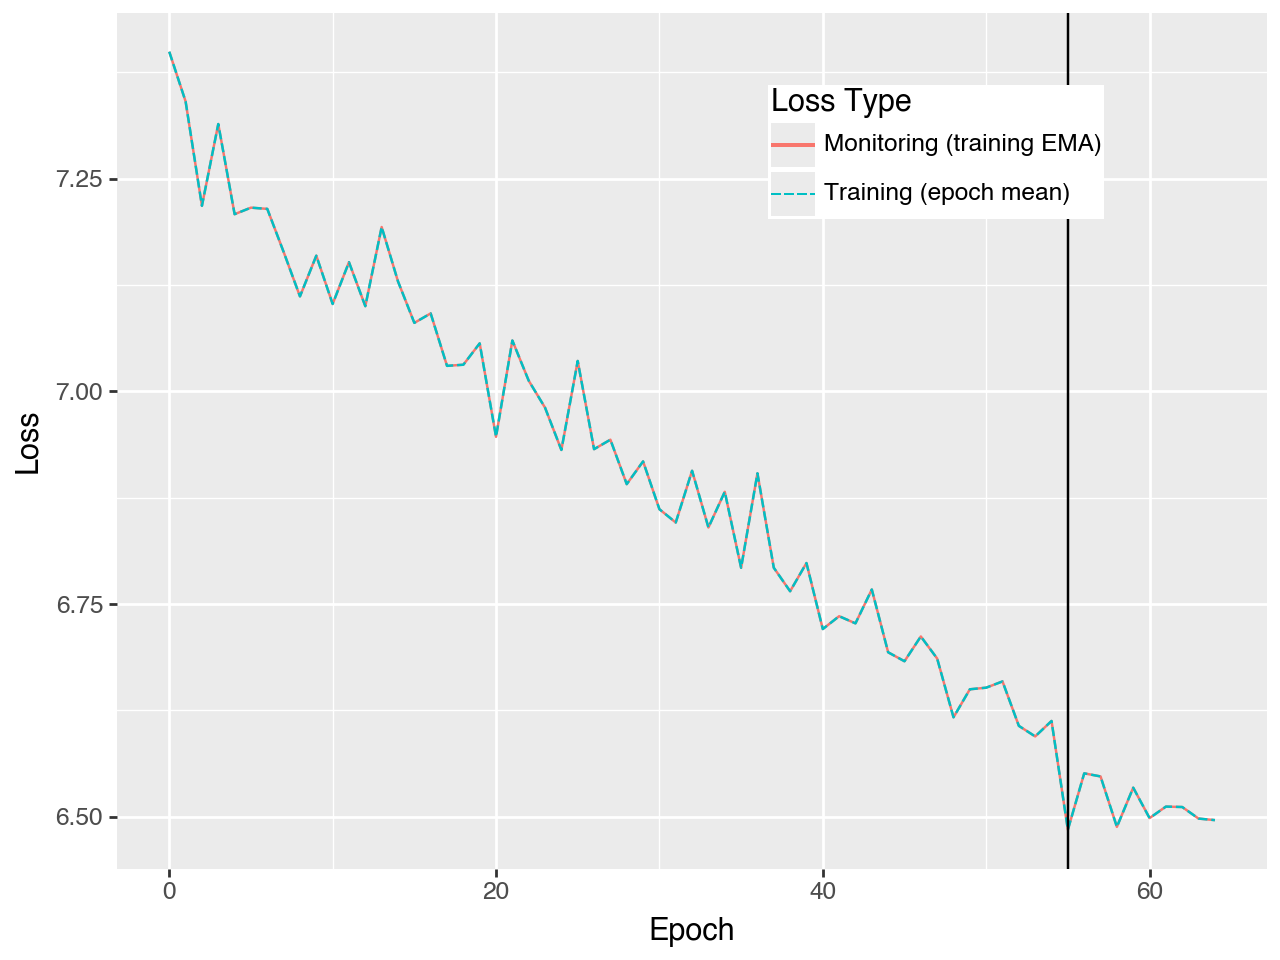

In [5]:
res.plot_loss()

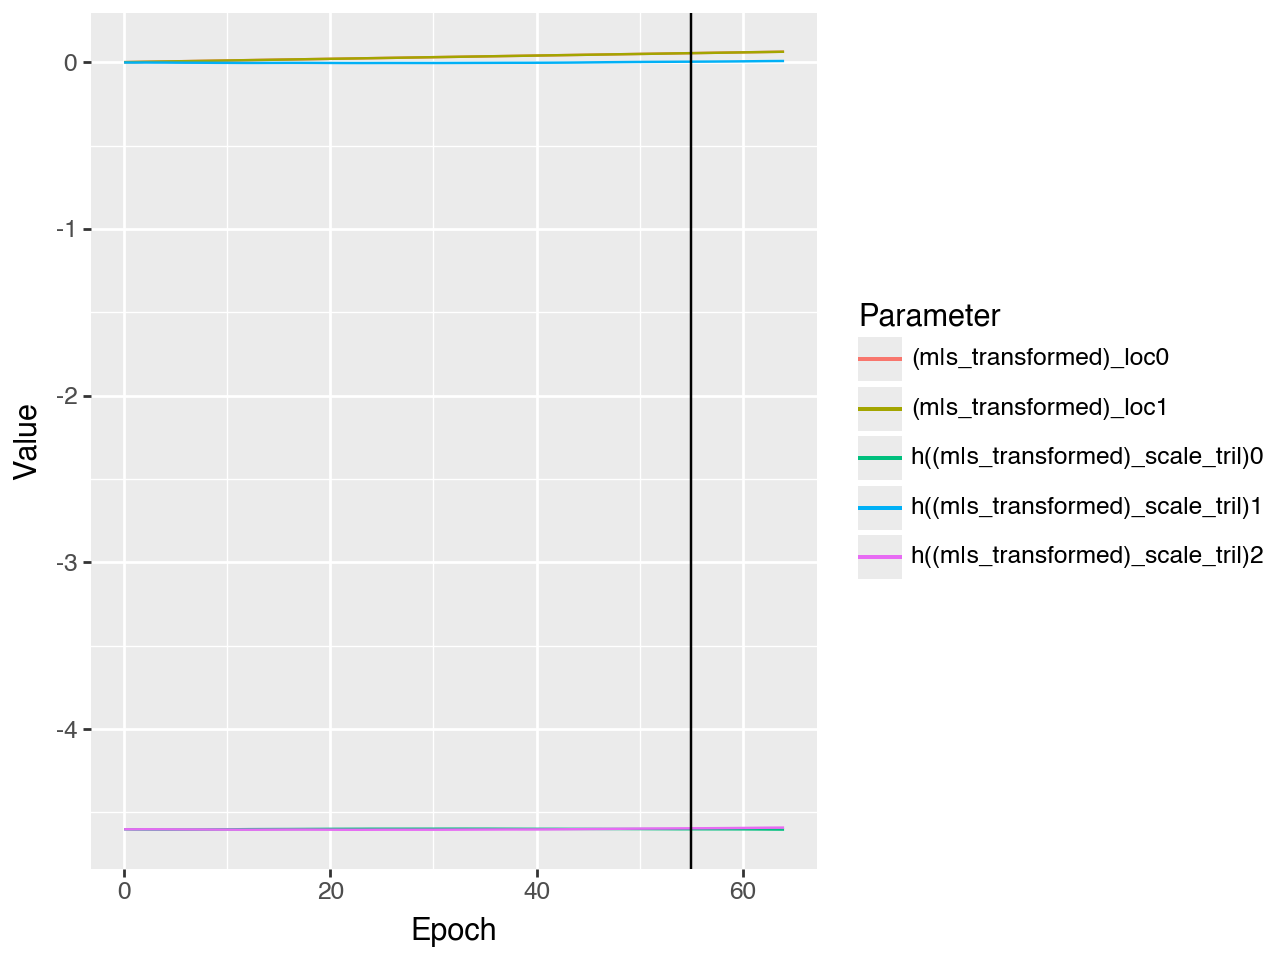

In [6]:
res.plot_params()